In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

c:\Users\Raghunandan\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [15]:
df=pd.read_csv('loan_train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [16]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [17]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode())

In [18]:
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode())

In [19]:
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].mean())

In [20]:
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())

In [23]:
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode())

In [74]:
df['Property_Area'].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

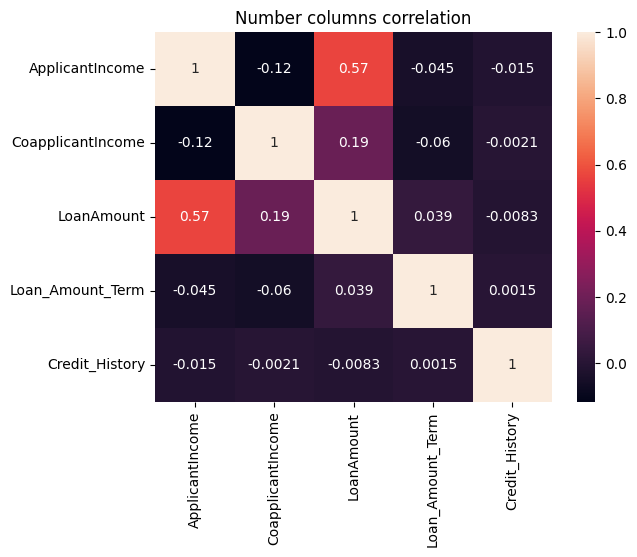

In [59]:
corr=df.select_dtypes(include='number').corr()
plt.title("Number columns correlation")
sns.heatmap(corr,annot=True)
plt.show()

In [63]:
# Select the features and target variable
x=df[['ApplicantIncome','Credit_History','LoanAmount','Loan_Amount_Term']]
y=df['Loan_Status'].map({'Y':1,'N':0})
print(x,y)

     ApplicantIncome  Credit_History  LoanAmount  Loan_Amount_Term
0               5849             1.0  146.412162             360.0
1               4583             1.0  128.000000             360.0
2               3000             1.0   66.000000             360.0
3               2583             1.0  120.000000             360.0
4               6000             1.0  141.000000             360.0
..               ...             ...         ...               ...
609             2900             1.0   71.000000             360.0
610             4106             1.0   40.000000             180.0
611             8072             1.0  253.000000             360.0
612             7583             1.0  187.000000             360.0
613             4583             0.0  133.000000             360.0

[614 rows x 4 columns] 0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64


In [64]:
# Split the train and test data
from sklearn.model_selection import train_test_split

In [65]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [66]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

In [67]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [68]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [69]:
model=Sequential([
    Dense(16,activation='relu',input_shape=(4,)),
    Dense(8,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [70]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [71]:
# Train the model
history=model.fit(x_train,y_train,epochs=50,validation_split=0.2,batch_size=32) # Use 20% of data for validation

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6811 - loss: 0.6940 - val_accuracy: 0.6970 - val_loss: 0.6873
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6964 - loss: 0.6847 - val_accuracy: 0.6970 - val_loss: 0.6817
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6964 - loss: 0.6795 - val_accuracy: 0.6970 - val_loss: 0.6763
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6964 - loss: 0.6742 - val_accuracy: 0.6970 - val_loss: 0.6710
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6964 - loss: 0.6689 - val_accuracy: 0.6970 - val_loss: 0.6663
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6964 - loss: 0.6643 - val_accuracy: 0.6970 - val_loss: 0.6613
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6964 - loss: 0.6594 - val_accuracy: 0.6970 - val_loss: 0.6566
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6964 - loss: 0.6550 - val_accuracy: 0.6970 - val_los

In [72]:
# Model Evaluation
loss,acc=model.evaluate(x_test,y_test)
print(f"Loss value : {loss}")
print(f"Accuracy : {acc}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6504 - loss: 0.6515 
Loss value : 0.6514807939529419
Accuracy : 0.6504064798355103


In [73]:
# Predictions
pred=model.predict(x_test)

# Convert probabilities into predictions
pred=(pred>0.5)
print(pred[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[[ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]]
